In [1]:
using FFTW
using GLMakie
using Statistics
using LinearAlgebra
using DSP

In [2]:
raw   = readlines("../SC_SDR/SC_DATA.csv")
data  = map(d -> parse.(Float64,d), split.(raw[length(raw)-8192+1:end], ","))
ts    = getindex.(data, 1)
reals = getindex.(data, 2)
imags = getindex.(data, 3)
vals  = reals .+ 1im .* imags
const SPS            = 10               # samples per symbol
const STEP           = 410              # step size
const PHASE_LUT_LEN  = 4096             # LUT length used in TX
const BETA           = 0.35             # RRC beta
const SPAN           = 6                # RRC span in symbols
const LEVELS         = [-3.0, -1.0, 1.0, 3.0]   # 16-QAM axis levels

# -----------------------------
# Utilities
# -----------------------------
slice_qam(z::Complex) = begin
    I = LEVELS[argmin(abs2.(real(z) .- LEVELS))]
    Q = LEVELS[argmin(abs2.(imag(z) .- LEVELS))]
    I + 1im*Q
end

function int_to_bits_msb(x::Integer, n::Integer)
    [ (x >> (n-1-k)) & 1 for k in 0:n-1 ]
end

function gray_bits_for_symbol(p::Complex)
    i_idx = argmin(abs2.(real(p) .- LEVELS)) - 1   # 0-based
    q_idx = argmin(abs2.(imag(p) .- LEVELS)) - 1   # 0-based
    i_gray = i_idx ⊻ (i_idx >> 1)
    q_gray = q_idx ⊻ (q_idx >> 1)
    vcat(int_to_bits_msb(i_gray, 2), int_to_bits_msb(q_gray, 2))
end

function bits_to_bytes(bits::Vector{Int}, bitoff::Int; maxchars::Int=120)
    nbytes = min((length(bits) - bitoff) ÷ 8, maxchars)
    out = UInt8[]
    sizehint!(out, nbytes)
    for i in 0:nbytes-1
        byte = UInt8(0)
        for b in bits[(bitoff + 1 + 8i):(bitoff + 8 + 8i)]
            byte = (byte << 1) | UInt8(b)
        end
        push!(out, byte)
    end
    out
end

bytes_to_display(bs::Vector{UInt8}) = join(Char.(bs))

function printable_ratio(bs::Vector{UInt8})
    isempty(bs) && return 0.0
    good = count(b -> (32 <= b < 127) || b in (0x09, 0x0A, 0x0D), bs)
    good / length(bs)
end

function text_score(bs::Vector{UInt8})
    isempty(bs) && return -1e9
    txt = lowercase(bytes_to_display(bs))
    printable = printable_ratio(bs)
    lowerfrac = count(c -> 'a' <= c <= 'z', txt) / max(length(txt), 1)
    spaces    = count(==(' '), txt) / max(length(txt), 1)

    # reward common lorem-ipsum-ish substrings if present
    common_words = ["lorem", "ipsum", "dolor", "sit", "amet",
                    "consectetur", "adipiscing", "elit", "maecen"]
    common = sum(occursin(w, txt) for w in common_words)

    3.0*printable + 1.5*lowerfrac + 2.0*spaces + 5.0*common
end

function unwrap_phase(ph::Vector{Float64})
    out = copy(ph)
    for i in 2:length(out)
        d = out[i] - out[i-1]
        if d > π
            out[i:end] .-= 2π
        elseif d < -π
            out[i:end] .+= 2π
        end
    end
    out
end

function mse_window(s::Vector{ComplexF64}; lo::Int=13, hi::Int=min(length(s), 140))
    hi <= lo && return Inf
    use = s[lo:hi]
    sh  = slice_qam.(use)
    mean(abs2.(use .- sh))
end

function dd_scalar_cleanup(s::Vector{ComplexF64}; lo::Int=13, hi::Int=min(length(s), 140), iters::Int=3)
    hi <= lo && return s
    sr = copy(s)
    for _ in 1:iters
        use = sr[lo:hi]
        sh  = slice_qam.(use)
        c   = sum(use .* conj.(sh)) / sum(abs2.(sh))
        sr ./= c
    end
    sr
end

function phase_slope_cleanup(s::Vector{ComplexF64}; lo::Int=13, hi::Int=min(length(s), 180))
    hi <= lo && return s, 0.0
    use = s[lo:hi]
    sh  = slice_qam.(use)
    err = unwrap_phase(angle.(use .* conj.(sh)))

    n = collect(0:length(err)-1)
    A = hcat(ones(length(n)), n)
    p = A \ err       # p[1] = constant phase, p[2] = slope

    nall = collect(0:length(s)-1)
    s2 = s .* exp.(-1im .* (p[1] .+ p[2] .* (nall .- (lo-1))))
    s2, p[2]
end

function symbol_stream_to_bits(s::Vector{ComplexF64})
    bits = Int[]
    sizehint!(bits, 4length(s))
    for z in s
        append!(bits, gray_bits_for_symbol(slice_qam(z)))
    end
    bits
end

function linconv(x::Vector{ComplexF64}, h::Vector{Float64})
    y = zeros(ComplexF64, length(x) + length(h) - 1)
    @inbounds for i in eachindex(x)
        xi = x[i]
        for j in eachindex(h)
            y[i+j-1] += xi * h[j]
        end
    end
    y
end

h0(b) = 1 + b*(4/π - 1)
h1(b) = b/sqrt(2) * ((1 + 2/π)*sin(π/(4b)) + (1 - 2/π)*cos(π/(4b)))
h_rrc(t, b) = t == 0 ? h0(b) :
              abs(t) == 1/(4b) ? h1(b) :
              (sin(π*t*(1-b)) + 4*b*t*cos(π*t*(1+b))) / (π*t*(1 - (4*b*t)^2))

ts_rrc = collect(-SPAN/2 : 1/SPS : SPAN/2)
hs = h_rrc.(ts_rrc, BETA)
hs ./= sqrt(sum(abs2, hs))
h_mf = reverse(hs)
gd = (length(h_mf) - 1) ÷ 2


I0 = findfirst(t -> t >= 0.0, ts)
I0 === nothing && error("Could not find t >= 0 in ts")

dc = mean(vals[1:max(1, I0-50)])
x0 = vals .- dc

best = nothing

# Search a small start offset around the trigger
for start_shift in -8:8
    start = I0 + start_shift
    (start < 1 || start > length(x0)-200) && continue

    x = x0[start:end]

    # Coarse frequency correction (undo TX shift)
    n = collect(0:length(x)-1)
    x = x .* exp.(-2π * 1im * STEP .* n ./ PHASE_LUT_LEN)

    # Matched filter
    y = linconv(x, h_mf)
    y = y[(gd+1):end]

    # Try all 10 timing phases
    for phase in 1:SPS
        s = y[phase:SPS:end]
        length(s) < 120 && continue

        lo = 13
        hi = min(length(s), 140)

        # Normalize to average 16-QAM symbol energy (= 10)
        s_norm = s ./ sqrt(mean(abs2.(s[lo:hi]))) .* sqrt(10)

        # -------- constant phase search --------
        thetas = range(-π, π; length=1441)
        best_phase_mse = Inf
        θbase = 0.0

        for θ in thetas
            sr = s_norm .* exp.(1im * θ)
            m = mse_window(sr; lo=lo, hi=hi)
            if m < best_phase_mse
                best_phase_mse = m
                θbase = θ
            end
        end

        # Also try π/2-related rotations explicitly
        for k in 0:3
            θ = θbase + k*(π/2)
            sr = s_norm .* exp.(1im * θ)

            # small DD cleanup
            sr = dd_scalar_cleanup(sr; lo=lo, hi=hi, iters=3)

            # optional residual phase slope cleanup
            sr2, slope = phase_slope_cleanup(sr; lo=lo, hi=min(length(sr), 180))
            if mse_window(sr2; lo=lo, hi=hi) < mse_window(sr; lo=lo, hi=hi)
                sr = sr2
            else
                slope = 0.0
            end

            # one more tiny cleanup after slope correction
            sr = dd_scalar_cleanup(sr; lo=lo, hi=hi, iters=2)

            # payload start + byte alignment search
            for sym_skip in 0:30
                sym_skip >= length(sr)-8 && continue
                payload = sr[(sym_skip+1):end]

                bits = symbol_stream_to_bits(payload)

                for bitoff in 0:7
                    bs = bits_to_bytes(bits, bitoff; maxchars=140)
                    score = text_score(bs)
                    mse   = mse_window(sr; lo=lo, hi=hi)

                    candidate = (
                        score      = score,
                        mse        = mse,
                        start_shift= start_shift,
                        phase      = phase,
                        theta      = θ,
                        slope      = slope,
                        sym_skip   = sym_skip,
                        bitoff     = bitoff,
                        text_bytes = bs,
                        text       = bytes_to_display(bs),
                        symbols    = sr,
                    )

                    if best === nothing ||
                       candidate.score > best.score ||
                       (candidate.score == best.score && candidate.mse < best.mse)
                        best = candidate
                    end
                end
            end
        end
    end
end

best === nothing && error("No decode candidate found.")

println("--------------------------------------------------")
println("BEST SETTINGS")
println("--------------------------------------------------")
println("start_shift = ", best.start_shift)
println("phase       = ", best.phase)
println("theta       = ", best.theta, " rad  = ", best.theta/π, " π")
println("slope       = ", best.slope, " rad/symbol")
println("sym_skip    = ", best.sym_skip)
println("bitoff      = ", best.bitoff)
println("mse         = ", best.mse)
println("score       = ", best.score)

println("\n--------------------------------------------------")
println("DECODED TEXT")
println("--------------------------------------------------")
println(best.text)

--------------------------------------------------
BEST SETTINGS
--------------------------------------------------
start_shift = 1
phase       = 3
theta       = 7.76235184824478 rad  = 2.470833333333333 π
slope       = 0.0 rad/symbol
sym_skip    = 2
bitoff      = 4
mse         = 0.03785953946111854
score       = 49.517857142857146

--------------------------------------------------
DECODED TEXT
--------------------------------------------------
Lorem ipsum dolor sit amet, consectetur adipiscing elit. Maecenas dolor risus, luctus ut lorem non, pharetra blandit velit. Duis consequat t


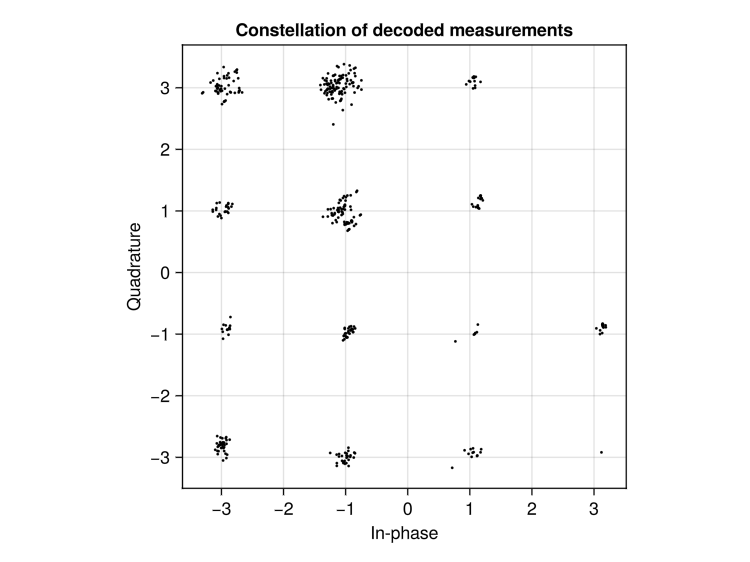

In [3]:
fig = Figure()
ax = Axis(fig[1,1],xlabel="In-phase",ylabel="Quadrature",title="Constellation of decoded measurements",
    aspect=AxisAspect(1),xticks=-3:1:3,yticks=-3:1:3)
scatter!(ax,real(best.symbols[4:end-3]),imag(best.symbols[4:end-3]),markersize=3,color=:black)
fig

In [4]:
points = best.symbols[4:end-3]
MQAM = 16
decision(x,L)=L[argmin(abs2.(real(x).-L))]+1im*L[argmin(abs2.(imag(x).-L))]
levels = collect(-(sqrt(MQAM)-1):2:(sqrt(MQAM)-1))
ds = map(x -> decision(x,levels),points)
EVM(X,X_hat) = sqrt(sum(abs2.(X-X_hat))/(sum(abs2.(X))))

EVM (generic function with 1 method)

In [5]:
EVM(ds,points), 20*log10(EVM(ds,points))

(0.06489709853730441, -23.755494389849684)

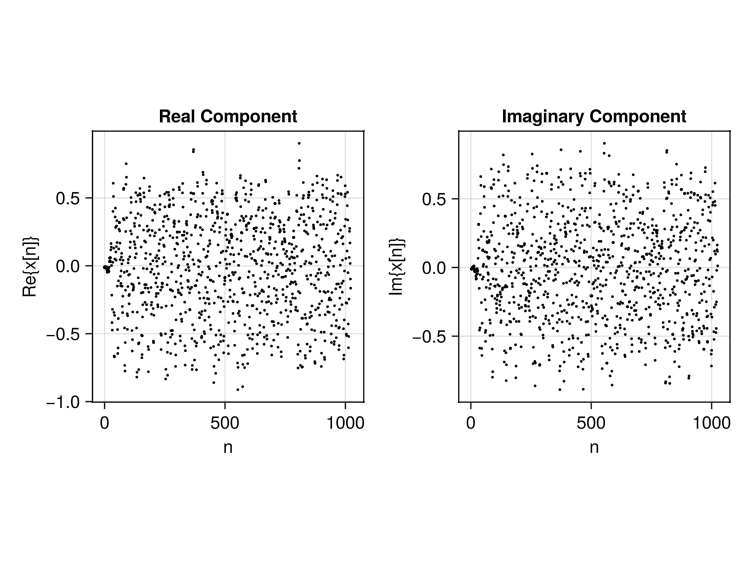

In [6]:
sym = vals[4096:4096+1024]
fig = Figure()
ax = Axis(fig[1,1],xlabel="n",ylabel="Re{x[n]}",title="Real Component",aspect=AxisAspect(1))
scatter!(ax,real.(sym),markersize=3,color=:black)
ax = Axis(fig[1,2],xlabel="n",ylabel="Im{x[n]}",title="Imaginary Component",aspect=AxisAspect(1))
scatter!(ax,imag.(sym),markersize=3,color=:black)
fig

In [7]:
PAPR_r = maximum(abs2.(real.(sym)))/mean(abs2.(real.(sym)))
PAPR_i = maximum(abs2.(imag.(sym)))/mean(abs2.(imag.(sym)))
PAPR = maximum(abs2.((sym)))/mean((abs2.(sym)))

3.271529835347485

In [8]:
PAPR_r,PAPR_i,PAPR

(6.020009003881992, 5.695906985253215, 3.271529835347485)

In [9]:
10*log10(PAPR_r),10*log10(PAPR_i),10*log10(PAPR)

(7.795971408148579, 7.55562888613158, 5.147508852847544)

In [10]:
log2(sqrt(PAPR_r)),log2(sqrt(PAPR_i)),log2(sqrt(PAPR))

(1.2948828223833677, 1.2549627935691503, 0.8549827138477838)